# LIBRARY

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from collections import defaultdict


In [8]:
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE

In [9]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [10]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [11]:
from imblearn.pipeline import Pipeline          # ← key fix
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [12]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np

class LogisticRegressionRandomSearch(BaseEstimator, ClassifierMixin):
    def __init__(self, n_iter=400, n_splits=5, random_state=42):
        self.n_iter       = n_iter
        self.n_splits     = n_splits
        self.random_state = random_state

        # populated after fit()
        self.best_model_  = None
        self.best_params_ = None
        self.best_score_  = None
        self.y_score_     = None
        self.info_        = None

    def fit(self, X, y):
        param_list = {
            'C':            [0.01,0.1, 1, 10, 100],
            'penalty':      ['l1', 'l2', 'elasticnet'],
            'solver':       ['saga'],
            'l1_ratio':     np.linspace(0, 1, 10).tolist(),
            'class_weight': ['balanced'],
            #'multi_class':  ['ovr','multinomial']
        }

        random_search = RandomizedSearchCV(
            LogisticRegression(),
            param_distributions=param_list,
            cv=KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state),
            scoring='f1_weighted',
            n_jobs=-1,
            refit=True,
            n_iter=self.n_iter,
            random_state=self.random_state,
        )
        random_search.fit(X, y)

        self.best_model_  = random_search.best_estimator_
        self.best_params_ = random_search.best_params_
        self.best_score_  = random_search.best_score_

        self.best_model_.fit(X, y)

        self.info_ = {
            'best_params':   self.best_params_,
            'best_cv_score': self.best_score_,
            'n_features':    self.best_model_.n_features_in_,
            'classes':       self.best_model_.classes_,
            'n_classes':     len(self.best_model_.classes_),
            'coef':          self.best_model_.coef_,
            'intercept':     self.best_model_.intercept_,
            'n_iter_':       self.best_model_.n_iter_,
            'cv_results':    random_search.cv_results_,
        }

        print("="*55)
        print("LOGISTIC REGRESSION — TRAINING SUMMARY")
        print("="*55)
        print(f"  Best params   : {self.best_params_}")
        print(f"  Best CV score : {self.best_score_:.4f}")
        print(f"  Classes       : {self.info_['classes']}")
        print(f"  Features used : {self.info_['n_features']}")
        print(f"  Converged in  : {self.info_['n_iter_']} iterations")
        print("="*55)

        return self                           # ← required by sklearn

    def predict(self, X):
        return self.best_model_.predict(X)

    def predict_proba(self, X):
        self.y_score_ = self.best_model_.predict_proba(X)
        return self.y_score_

# READ DATAFRAME

In [59]:
file_path = "../1.DATASET/CMI_FINAL_OD_SS.csv"
df=pd.read_csv(file_path)

In [60]:
df

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
0,0,-1.467073,-0.822843,-0.561893,-1.343231,-1.008221,-0.250870,-0.956432,-0.428812,-0.942872,-0.939966,-0.992591,-0.818300,-0.947148,-0.726336,-1.265162,-0.874740,-0.859871,2.0
1,1,-0.338700,-0.822843,-1.221382,-1.083906,-1.128018,0.630346,-0.657546,-0.367405,1.285851,-0.939966,-1.033298,-0.804797,-0.932563,-1.053662,-1.265162,-1.226847,-1.273565,0.0
2,2,-0.056607,1.215298,-0.614950,0.018225,-0.389269,-0.232187,1.018179,-1.466511,0.790579,0.280796,-0.662859,-0.199213,-0.347769,-0.314411,0.512640,-0.355318,-0.148634,0.0
3,3,-0.338700,-0.822843,-0.233502,-0.046607,-0.239523,-0.577200,0.665395,-0.367405,-0.695236,0.280796,-0.456268,0.057750,-0.249394,-0.126332,0.512640,-0.283279,0.116846,1.0
4,4,2.200139,1.215298,-0.315811,-0.224763,-0.375806,0.577087,-0.304761,1.210082,-0.198377,0.280796,3.297345,1.538145,-0.330005,-0.314411,0.512640,0.009328,-0.148634,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8377,8455,-0.902887,1.215298,-0.735189,-1.334155,-1.060626,-0.281071,-0.789840,-0.392148,-0.695236,-2.160727,-1.012064,-0.820639,-0.817405,-1.103413,-1.265162,-1.004029,-0.941197,0.0
8378,8456,-0.056607,1.215298,-0.463799,-0.029751,-0.341052,-0.490946,-0.613448,-1.251639,-1.685780,0.280796,0.067523,-0.439950,-0.015430,-0.823890,-1.265162,-0.581341,-0.582047,1.0
8379,8457,-0.056607,1.215298,5.021847,-0.881633,1.293649,-0.249437,0.533101,-0.627980,0.542943,1.501557,-0.388344,-0.705917,1.239140,0.886735,0.512640,0.152734,-0.682526,0.0
8380,8458,1.353859,1.215298,0.742981,0.963464,0.974332,0.395292,-0.481153,1.201246,1.038215,-0.939966,0.058376,-0.447250,1.092211,0.366529,0.512640,1.420549,0.963516,2.0


In [61]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])


# Data Preparation

In [62]:
X.shape

(8382, 17)

In [63]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3.]), array([5794, 1567,  936,   85], dtype=int64))

In [64]:
Counter(y)

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

In [65]:
ctr = Counter(y)
ctr

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

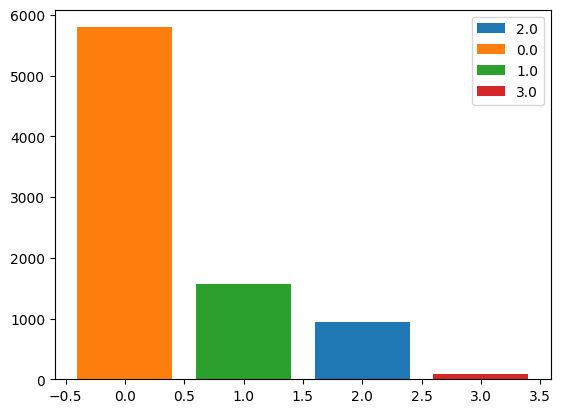

In [66]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange','tab:green','tab:red'])
plt.legend()
plt.show()

## Data Partitioning

In [67]:
from sklearn.model_selection import train_test_split, cross_val_score 

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [69]:
X_train.shape

(5867, 17)

In [70]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0., 1., 2., 3.]), array([4056, 1097,  655,   59], dtype=int64)),
 (array([0., 1., 2., 3.]), array([1738,  470,  281,   26], dtype=int64)))

In [71]:
np.max(np.unique(y_train, return_counts=True)[1])/len(X_train)

0.6913243565706494

# PIPELINE

In [72]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [73]:
over_dic={1:2500,2:2000,3:1500}
under_dic={0:3000}

In [74]:
over = SMOTE(random_state=42, sampling_strategy=over_dic)
under = TomekLinks(sampling_strategy='majority')

## Logistic Regression RandomSearch

In [75]:
from imblearn.pipeline import Pipeline

pipeline = Pipeline([
    #('over',  over),
    #('under', under),
    ('clf',   LogisticRegressionRandomSearch())
])


pipeline.fit(X_train, y_train)
y_pred  = pipeline.predict(X_test)
y_score = pipeline.predict_proba(X_test)

c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 150 is smaller than n_iter=400. Running 150 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_r

LOGISTIC REGRESSION — TRAINING SUMMARY
  Best params   : {'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 0.7777777777777777, 'class_weight': 'balanced', 'C': 0.01}
  Best CV score : 0.5404
  Classes       : [0. 1. 2. 3.]
  Features used : 17
  Converged in  : [32] iterations


In [76]:
info = pipeline['clf'].info_

print(info['best_params'])
print(info['best_cv_score'])

{'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 0.7777777777777777, 'class_weight': 'balanced', 'C': 0.01}
0.5403945028581922


In [77]:
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5001988071570577
F1-score [0.70453095 0.19327731 0.22900763 0.03795066]
              precision    recall  f1-score   support

         0.0       0.79      0.64      0.70      1738
         1.0       0.28      0.15      0.19       470
         2.0       0.20      0.27      0.23       281
         3.0       0.02      0.38      0.04        26

    accuracy                           0.50      2515
   macro avg       0.32      0.36      0.29      2515
weighted avg       0.62      0.50      0.55      2515



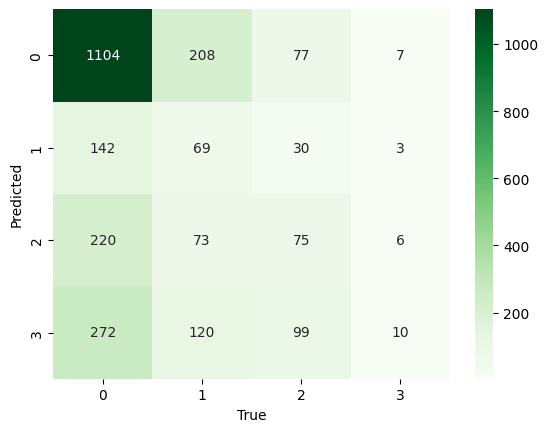

In [78]:
cf = confusion_matrix(y_pred,y_test)
sns.heatmap(cf, annot=True, cmap="Greens",fmt='g')
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

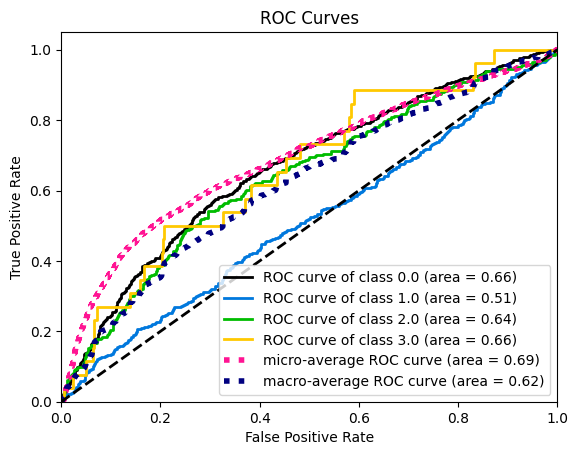

In [79]:
# roc
plot_roc(y_test, y_score)
plt.show()